In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

file = '../Scenario_Analysis_FINAL.xlsx'

# --- Load and shape data ---
df = pd.read_excel(file, sheet_name='ObjFunc')

# first 6 scenarios, set Scenario as index
df = df.iloc[:6].set_index('Scenario')

# keep only from Buy_Electricity to Total Profit (adjust first col name if needed)
df = df.loc[:, 'Buy_Electricity':'Total Profit']

# remove columns that dont contribute much
remove_cols = ['Variable_OM_ElectricStorage', 'Variable_OM_Boiler']
df = df.drop(columns=remove_cols)

df

,Buy_Electricity,Buy_NatGas Import,Sell_Electricity,Sell_H2,Variable_OM_WindTurbine,Variable_OM_Digester,Variable_OM_BiogasUpgrade,Variable_OM_CO2Compressor,Total Profit
Scenario,,,,,,,,,
Baseline,-727538.251029,-348457.460023,2468064.695403,0.000000,-242836.012741,-376900.615579,-214285.714286,0,544039.858509
NoStorageCO2,-731867.810763,-348579.866792,2464813.119038,0.000000,-242794.403893,-376900.615579,-214285.714286,0,536367.039171
NoStorageALL,-621958.013551,-348997.670542,1973502.549563,0.000000,-240142.9903,-376900.615579,-214285.714286,0,159031.236018
H2,-843487.480678,-348454.267283,2299154.808707,302763.898347,-242836.012741,-376900.615579,-214285.714286,0,561909.120997
BioFixed,-790371.138419,-681197.224356,2372725.836215,0.000000,-242919.231968,-835463.031201,-475000.0,0,-677847.549903
CO2Trans,-728181.05646,-348459.871715,2468686.725919,0.000000,-242836.012741,-376900.615579,-214285.714286,-96364.8,447652.286514


In [12]:

# rename columns
df = df.rename(columns={
    'Buy_Electricity': 'Electricity Purchase',
    'Buy_NatGas Import': 'Natural Gas Import',
    'Sell_Electricity': 'Electricity Sales',
    'Sell_H2': 'Hydrogen Sales',
    'Variable_OM_WindTurbine': 'O&M Wind Turbine',
    'Variable_OM_Digester': 'O&M Digester',
    'Variable_OM_BiogasUpgrade': 'O&M Biogas Upgrade',
    'Variable_OM_CO2Compressor': 'Transportation',
    'Total Profit': 'Profit'
})

profit_col = 'Profit'
bar_cols = [c for c in df.columns if c != profit_col]

# scaling for nicer units
scale = 100000
df_plot = df / scale

df_plot

,Electricity Purchase,Natural Gas Import,Electricity Sales,Hydrogen Sales,O&M Wind Turbine,O&M Digester,O&M Biogas Upgrade,Transportation,Profit
Scenario,,,,,,,,,
Baseline,-7.275383,-3.484575,24.680647,0.000000,-2.42836,-3.769006,-2.142857,0.0,5.440399
NoStorageCO2,-7.318678,-3.485799,24.648131,0.000000,-2.427944,-3.769006,-2.142857,0.0,5.36367
NoStorageALL,-6.21958,-3.489977,19.735025,0.000000,-2.40143,-3.769006,-2.142857,0.0,1.590312
H2,-8.434875,-3.484543,22.991548,3.027639,-2.42836,-3.769006,-2.142857,0.0,5.619091
BioFixed,-7.903711,-6.811972,23.727258,0.000000,-2.429192,-8.35463,-4.75,0.0,-6.778475
CO2Trans,-7.281811,-3.484599,24.686867,0.000000,-2.42836,-3.769006,-2.142857,-0.963648,4.476523


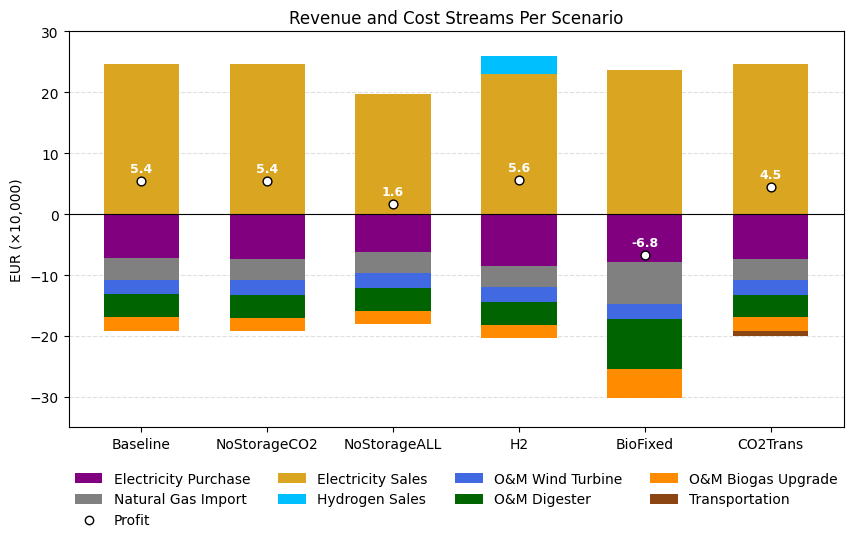

In [15]:

colors = {
    'Electricity Purchase':      'purple',
    'Natural Gas Import':        'grey',
    'Electricity Sales':         'goldenrod',
    'Hydrogen Sales':            'deepskyblue',
    'O&M Wind Turbine':          'royalblue',
    'O&M Digester':              'darkgreen',
    'O&M Biogas Upgrade':        'darkorange',
    'Transportation':            'saddlebrown',
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_plot))
width = 0.6

used_labels = set()

for i, (scenario, row) in enumerate(df_plot.iterrows()):
    bottom_pos = 0
    bottom_neg = 0

    for col in bar_cols:
        value = row[col]
        if value == 0:
            continue

        # label only the first non-zero occurrence of each column
        label = col if col not in used_labels else None

        if value > 0:
            ax.bar(
                x[i],
                value,
                width,
                bottom=bottom_pos,
                label=label,
                color=colors[col]
            )
            bottom_pos += value
        else:
            ax.bar(
                x[i],
                value,
                width,
                bottom=bottom_neg,
                label=label,
                color=colors[col]
            )
            bottom_neg += value

        if label is not None:
            used_labels.add(col)

    # profit marker + label
    profit = row[profit_col]
    ax.scatter(x[i], profit, s=40, facecolor="white", edgecolor="black", zorder=3)
    ax.text(
        x[i], 
        profit + 1,
        f"{profit:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight='bold',
        color="white"
    )

ax.set_xticks(x)
ax.set_xticklabels(df_plot.index)

ax.set_ylabel("EUR (×10,000)")
ax.set_title("Revenue and Cost Streams Per Scenario")

ax.axhline(0, color="black", linewidth=0.8)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

ax.set_ylim(-35, 30)

plt.rcParams["font.size"] = 10
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10

# --- Legend ---

# Put Profit as the 3rd element
bar_order = [
    "Electricity Purchase",
    "Natural Gas Import",
    "Profit",               # ← Profit now 3rd in list
    "Electricity Sales",
    "Hydrogen Sales",
    "O&M Wind Turbine",
    "O&M Digester",
    "O&M Biogas Upgrade",
    "Transportation",
]

legend_handles = []
for label in bar_order:
    if label == "Profit":
        handle = Line2D(
            [], [], 
            marker='o',
            linestyle='None',
            markersize=6,
            markerfacecolor='white',
            markeredgecolor='black',
            label=label
        )
    else:
        handle = Patch(facecolor=colors[label], label=label)

    legend_handles.append(handle)

plt.subplots_adjust(bottom=0.22)

ax.legend(
    legend_handles,
    bar_order,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=4,          # 4 columns → Profit goes to col 3 in row 1
    frameon=False
)


plt.savefig("rev_cost_streams.pdf", bbox_inches="tight")
plt.show()
